# Mean Reversion OOS Test (Using Rolling PCA)

Lastly, we test our cross-sectional mean reversion strategy on an unseen dataset spanning January 2025 to February 2026, using 4-hour crypto data across a universe of 70 assets. This section can be read as a self-contained summary of the strategy and its out-of-sample performance.

### Strategy overview

The strategy uses rolling PCA to decompose asset returns into a common market factor and an idiosyncratic residual component. By removing the dominant principal component, which we show explains 50-70% of cross-sectional return variance and represents a diffuse equal-weight market factor, we isolate the idiosyncratic return of each asset. The strategy assumes this idiosyncratic component is mean reverting over short horizons: assets that have recently outperformed relative to the market factor are expected to give back those gains, and vice versa. We therefore go long assets with the most negative residuals and short those with the most positive residuals, constructing a dollar-neutral portfolio with no net directional market exposure.

To make the strategy viable after transaction costs, we apply two smoothing mechanisms. First, residuals are smoothed using an exponential weighted moving average (EWM, alpha=0.5) before signal construction. Second, portfolio weights are partially adjusted at each rebalance, blending target weights with the previous period's weights at rate rho=0.95, which reduces turnover and extends the average holding period to approximately 5.6 days. Without these adjustments the strategy would be unprofitable at 20bps transaction costs due to excessive turnover.

### Parameter selection

Parameters were selected via a grid search on the in-sample training period (2022-2024), optimising for net Sharpe ratio. The optimal configuration uses 1 principal component, a 30-day rolling window, rho=0.95, alpha=0.5, and a rank threshold of 0.05, meaning only the top and bottom 5% of assets by residual magnitude are assigned non-zero weights at each rebalance.

### Out-of-sample results

The strategy achieves a gross Sharpe ratio of 2.38 and net Sharpe ratio of 1.10 on the unseen out-of-sample dataset, with an annualised alpha of 24.3% and alpha t-statistic of 2.57, exceeding the 1% significance threshold and confirming the excess returns are statistically significant. Beta is effectively zero (0.004), confirming the strategy maintains its market-neutral character throughout. These results are notably consistent with the in-sample performance, suggesting the strategy generalises well and the signal is genuine rather than an artefact of parameter overfitting.

This stands in stark contrast to the OLS method tested over the same period, which produces a gross Sharpe of 0.87 and a negative net Sharpe of -0.40. We attribute this divergence to the ETH-specific underperformance through 2025, the fixed ETH market proxy used in OLS becomes a poor representation of the true market factor as ETH decouples from the broader altcoin universe, contaminating the residuals. PCA's rolling factor extraction adapts dynamically to the shifting covariance structure, making it more resilient to regime changes and a more robust choice for isolating idiosyncratic returns in the crypto universe.

In [1]:
cd -q ../../

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.backtest.backtest import run_backtest_oos
from src.backtest.helpers import sharpe
from src.analysis.stats import rolling_sharpe, plot_drawdown

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

## Data

In [3]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"

In [4]:
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets = pd.read_parquet(rets_parquet_path)
px = pd.read_parquet(px_parquet_path)
px = px.loc["20240601":]

## Results of Out-of-sample Test

The out-of-sample results for the PCA method are markedly stronger than the OLS counterpart, demonstrating the advantage of a data-driven factor extraction approach over a fixed market proxy in a shifting regime.

The gross Sharpe ratio of 2.38 and net Sharpe ratio of 1.10 are remarkably consistent with the in-sample figures of 2.35 and 1.14 respectively, suggesting the strategy generalises well out of sample. This consistency is the most compelling finding of the analysis, and it indicates the mean reversion signal captured by PCA residuals is genuine and persistent rather than an artefact of in-sample parameter selection.

The annualised alpha of 24.3% with a t-statistic of 2.57 exceeds the 1% significance threshold (2.576), confirming statistically significant excess returns in the out-of-sample period. Beta is effectively zero at 0.004 and R-squared is negligible at 0.025%, confirming the strategy maintains its market-neutral character with no meaningful exposure to BTC price movements.

The hit rate of 0.550 is virtually identical to the in-sample figure of 0.55, and average turnover of 0.030 is stable, indicating the signal quality and portfolio construction are both consistent across the two periods. The annualised cost drag of 13.0% against a gross return of 24.3% gives a net return of approximately 11.3%, consistent with the reported net Sharpe.

The contrast with the OLS out-of-sample results is stark: where OLS alpha becomes statistically insignificant (t-stat 0.99) and net Sharpe turns negative, PCA maintains a significant alpha t-statistic of 2.57 and a net Sharpe of 1.10 over the same period. This divergence directly supports the hypothesis that ETH's idiosyncratic underperformance through 2025 contaminated the OLS residuals, whereas PCA's rolling factor extraction adapted to the changing covariance structure and continued to isolate genuinely idiosyncratic returns.

In [5]:
oos = run_backtest_oos(
    px,
    freq="4h", 
    rho=0.95, 
    rank_thresh=0.05, 
    alpha=0.5, 
    n_comp=1, 
    window_size=6*30, 
    method="pca",
    oos_start="2025-01-01"
    )

2026-03-05 01:48:41,083 INFO: Resampled to 4h


In [6]:
pd.DataFrame({x: y for x,y in oos.items() if type(y) is np.float64}, index=["oos"])

,avg_holding_days,gross_sharpe,net_sharpe,avg_ann,vol_ann,alpha_ann,alpha_tstat,beta,hit_rate,r_squared,avg_turnover,cost_drag_ann
oos,5.561837,2.376596,1.100989,0.242653,0.102101,0.243386,2.566394,0.003618,0.549823,0.000254,0.029749,0.130299


### Information Coefficient (IC) Analysis

The following IC decay plot confirms the mean reversion signal found during our backtest persists out of sample, but again decays quickly.

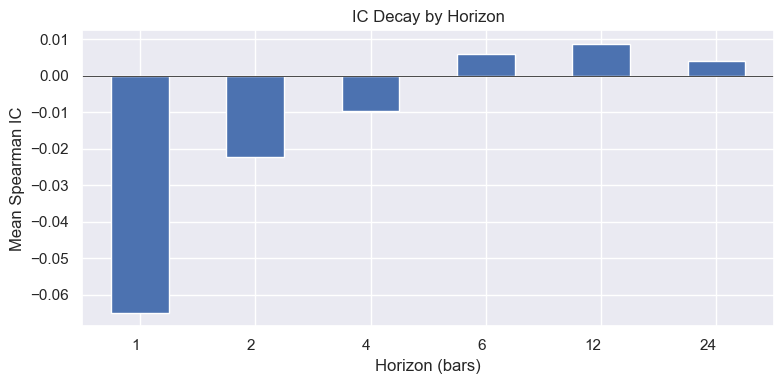

In [7]:
ic = oos["ic"]

pd.Series(ic).plot(kind="bar", figsize=(8, 4), title="IC Decay by Horizon")
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Horizon (bars)")
plt.ylabel("Mean Spearman IC")
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### Rolling net sharpe ratio

The rolling net Sharpe ratio is generally positive and strong throughout the out-of-sample period, with the notable exception of late 2025 where performance deteriorates materially. This coincides with broader crypto bear market conditions, during which cross-sectional return dispersion compresses and mean reversion opportunities become scarcer, the same dynamic observed in the in-sample regime analysis. This suggests the strategy is sensitive to market regime, performing well during periods of high idiosyncratic volatility but struggling when assets move in a more uniform, directional fashion. Incorporating a regime filter (for instance conditioning position sizing on rolling cross-sectional dispersion or PC1 explained variance) could potentially improve risk-adjusted returns by reducing or eliminating exposure during unfavourable regimes.

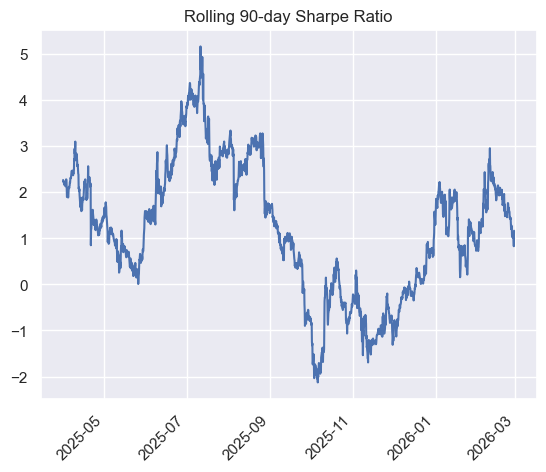

In [8]:
gross_ret = oos["gross_ret"]
net_ret = oos["net_ret"]

roll_sharpe = rolling_sharpe(net_ret)

### Cumulative returns

Our out-of-sample cumulative returns outperform BTC buy-and-hold throughout the period, with the gap widening considerably from late 2025 onwards as bear market conditions take hold. While BTC experiences significant drawdowns during this period, the strategy's market-neutral construction insulates it from directional losses, generating positive cumulative returns despite the adverse macro environment. This outperformance during a bear market is particularly meaningful from a portfolio construction perspective, a strategy that is uncorrelated with market direction and generates positive returns during drawdowns provides genuine diversification value that a passive BTC position cannot. The fact that the PCA method maintains positive net cumulative returns and a net Sharpe of 1.10 over a period that includes a significant bear market episode further validates the robustness of the approach and its advantage over the OLS method, which failed to remain profitable over the same period.

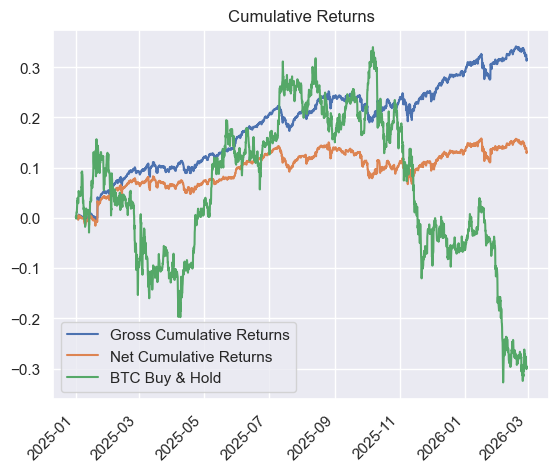

In [9]:
gross_cum = oos["gross_cum"]
net_cum = oos["net_cum"]

rets = rets.loc["20250101":]
btc_cum = (1 + rets["BTCUSDT"]).cumprod() - 1

plt.plot(gross_cum, label="Gross Cumulative Returns")
plt.plot(net_cum, label="Net Cumulative Returns")
plt.plot(btc_cum, label="BTC Buy & Hold")
plt.title("Cumulative Returns")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Drawdown

Our most notable drawdown period spans approximately 100 days from September 2025 through to January 2026, reaching a trough of -0.07. This coincides with the broader crypto bear market conditions identified in the cumulative returns analysis, where rising cross-sectional correlation compressed idiosyncratic return dispersion and weakened the mean reversion signal. Notably, despite this being an adverse regime, the maximum drawdown of -0.07 is relatively modest, shallower than the -0.125 maximum drawdown observed in the in-sample period, and the strategy recovers by January 2026, suggesting the signal degradation is temporary rather than structural. The drawdown duration of 100 days is also consistent with a regime-driven episode rather than a fundamental breakdown in the strategy, as the recovery coincides with a stabilisation in market conditions. The fact that the strategy navigates this drawdown period while still delivering a net Sharpe of 1.10 over the full out-of-sample window underscores the resilience of the PCA approach relative to OLS, which did not recover over the same period.

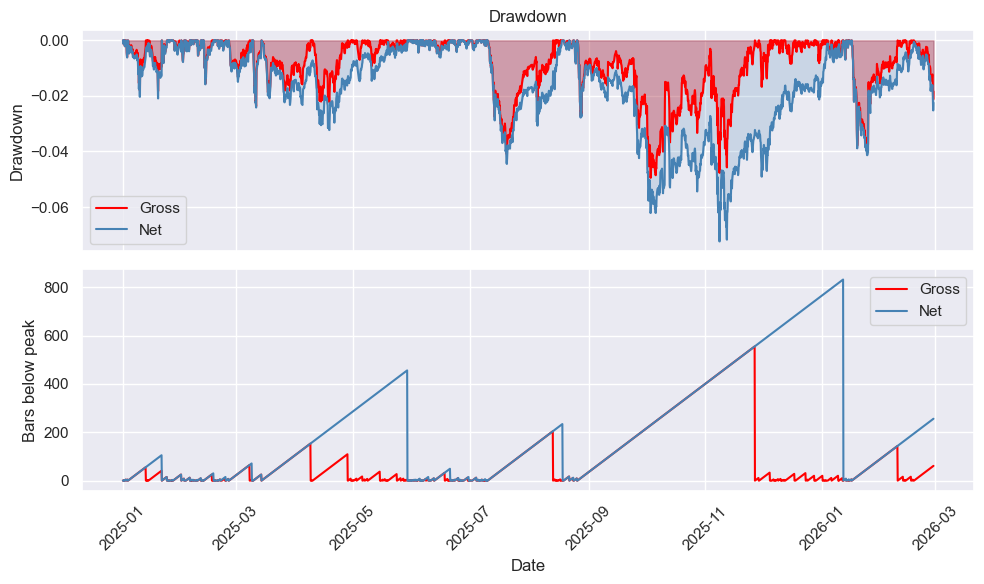

In [10]:
plot_drawdown(gross_ret, net_ret, title = "Drawdown")

### Cost analysis

Turnover remains stable throughout the out-of-sample period, averaging 0.030 per bar, virtually identical to the in-sample figure of 0.029, as a result of the smoothing mechanisms put in place. The partial adjustment parameter (rho=0.95) and EWM residual smoothing (alpha=0.5) continue to effectively limit portfolio churn even during the drawdown period of September 2025 to January 2026, when a less constrained strategy might increase turnover in response to larger signal movements during volatile bear market conditions. This stability in turnover is important for two reasons: it confirms the cost drag assumption of approximately 13% annualised remains valid throughout the out-of-sample period and does not spike during adverse regimes, and it demonstrates that the smoothing parameters generalise well out of sample rather than being overfit to the specific turnover characteristics of the training period.

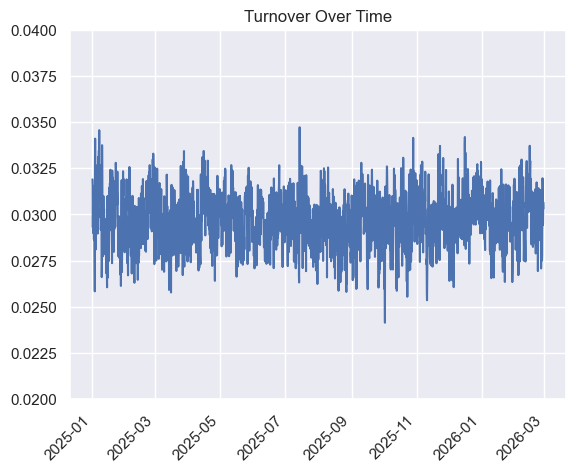

In [11]:
to = oos["to"]
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 15 * BARS_PER_DAY
ann_factor = 365 * BARS_PER_DAY

plt.plot(to)
plt.title("Turnover Over Time")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.02, 0.04)
plt.show()

In the following, we show that as transaction costs increase beyond our 20bps baseline assumption, strategy performance degrades materially. At 30bps the net Sharpe falls to 0.54, and at 40bps the strategy becomes marginally unprofitable with a net Sharpe of -0.18. This sensitivity is consistent with what was observed in the in-sample tests, suggesting the narrow margin of safety between gross and net returns is a structural characteristic of the strategy rather than a period-specific artefact.

The core issue is that the annualised cost drag of approximately 13% leaves limited headroom, and gross annualised returns of 24.3% must absorb transaction costs before delivering net returns, meaning any increase in execution costs beyond 20bps erodes this buffer quickly. At a blended cost assumption of 25-30bps across the full universe, which may be more realistic given the mix of large and mid-cap assets, the net Sharpe would likely fall to the 0.5-0.8 range, which while still positive represents a meaningful reduction in risk-adjusted returns.

This is a relevant concern for smaller-cap assets in our universe where bid-ask spreads are wider and market impact is higher. For the most liquid names such as BTC and ETH, 20bps is a reasonable assumption for a taker strategy with modest position sizes, but for the lower-liquidity tail of the universe this figure may be optimistic. In practice, a tiered cost assumption, lower for large caps and higher for mid-caps, would give a more accurate picture of true net performance than the uniform 20bps applied here.

The strategy's sensitivity to transaction costs therefore represents a key limitation of this approach, and improving net performance would likely require either tighter execution, through limit orders or algorithmic execution to reduce market impact, or restricting the universe to the most liquid assets where the 20bps assumption is most defensible.

In [12]:
for bps in [15, 20, 30, 40]:
    net = gross_ret - to * bps * 1e-4
    print(f"{bps:3d}bps: net Sharpe = {sharpe(net, ann_factor):.2f}")

 15bps: net Sharpe = 1.42
 20bps: net Sharpe = 1.10
 30bps: net Sharpe = 0.46
 40bps: net Sharpe = -0.18
